In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/drsinglabhawnasingla/saraga-carnatic-dataset/saraga1.5_carnatic/file_paths.csv
/kaggle/input/datasets/drsinglabhawnasingla/saraga-carnatic-dataset/saraga1.5_carnatic/Akkarai Sisters at Arkay by Akkarai Sisters/Geeta Nayakan/Geeta Nayakan.multitrack-mridangam-right.mp3
/kaggle/input/datasets/drsinglabhawnasingla/saraga-carnatic-dataset/saraga1.5_carnatic/Akkarai Sisters at Arkay by Akkarai Sisters/Geeta Nayakan/Geeta Nayakan.json
/kaggle/input/datasets/drsinglabhawnasingla/saraga-carnatic-dataset/saraga1.5_carnatic/Akkarai Sisters at Arkay by Akkarai Sisters/Geeta Nayakan/Geeta Nayakan.sama-manual.txt
/kaggle/input/datasets/drsinglabhawnasingla/saraga-carnatic-dataset/saraga1.5_carnatic/Akkarai Sisters at Arkay by Akkarai Sisters/Geeta Nayakan/Geeta Nayakan.multitrack-ghatam.mp3
/kaggle/input/datasets/drsinglabhawnasingla/saraga-carnatic-dataset/saraga1.5_carnatic/Akkarai Sisters at Arkay by Akkarai Sisters/Geeta Nayakan/Geeta Nayakan.bpm-manual.txt
/kaggle/input/

In [19]:
# ==========================================================
# Cell 1 : Install Required Packages
# ==========================================================

!pip -q install torchcrepe librosa soundfile tqdm

In [2]:
import os

PROJECT = "/kaggle/working/SwaraFormer"

folders = [
    "notebooks",
    "models",
    "utils",
    "dataset",
    "dataset/subset",
    "dataset/processed",
    "dataset/embeddings",
    "checkpoints",
    "results",
    "results/figures",
    "results/confusion_matrix",
    "results/logs"
]

for folder in folders:
    os.makedirs(os.path.join(PROJECT, folder), exist_ok=True)

print("Project created successfully.")

Project created successfully.


In [3]:
files = [
    "config.py",

    "models/__init__.py",
    "models/encoder.py",
    "models/transformer.py",
    "models/bilstm.py",
    "models/conformer.py",
    "models/losses.py",

    "utils/__init__.py",
    "utils/audio.py",
    "utils/features.py",
    "utils/dataset.py",
    "utils/metrics.py",
    "utils/visualization.py",
]

for f in files:

    path = os.path.join(PROJECT, f)

    with open(path, "w") as fp:
        fp.write("")

print("Python files created.")

Python files created.


In [4]:
# ==========================================================
# Cell 1 : Install Dependencies
# ==========================================================

!pip install -q torchcrepe librosa soundfile audiomentations
!pip install -q pandas numpy matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 MB 22.2 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 75.1 MB/s eta 0:00:00:00:01


In [5]:
# ==========================================================
# Cell 2 : Imports
# ==========================================================

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import librosa
import soundfile as sf

import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn.functional as F
import torchcrepe

In [9]:
# ==========================================================
# Cell 3 : Configuration
# ==========================================================

# Root dataset directory
DATASET_DIR = "/kaggle/input/datasets/drsinglabhawnasingla/saraga-carnatic-dataset/saraga1.5_carnatic"

# Project directory
PROJECT_DIR = "/kaggle/working/SwaraFormer"

# Audio
SAMPLE_RATE = 16000

# Spectrogram
N_MELS = 64
FFT_SIZE = 1024
HOP_LENGTH = 160

# Windowing
WINDOW_SIZE = 256

# Small subset for development
SUBSET_SIZE = 20

# Random seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device :", DEVICE)

Device : cpu


In [10]:
# ==========================================================
# Cell 4 : Create Project Structure
# ==========================================================

folders = [

    "dataset",

    "dataset/raw",

    "dataset/subset",

    "dataset/processed",

    "dataset/embeddings",

    "models",

    "utils",

    "results",

    "results/figures",

    "results/logs",

    "checkpoints"

]

for folder in folders:

    os.makedirs(
        os.path.join(PROJECT_DIR, folder),
        exist_ok=True
    )

print("Project structure created successfully.")

Project structure created successfully.


In [11]:
# ==========================================================
# Cell 5 : Index Dataset
# ==========================================================

songs = []

for root, dirs, files in os.walk(DATASET_DIR):

    audio = None
    pitch = None
    tonic = None
    metadata = None

    for f in files:

        if f.endswith(".mp3.mp3"):

            audio = os.path.join(root, f)

        elif f.endswith(".pitch.txt"):

            pitch = os.path.join(root, f)

        elif f.endswith(".ctonic.txt"):

            tonic = os.path.join(root, f)

        elif f.endswith(".json"):

            metadata = os.path.join(root, f)

    if audio and pitch and tonic:

        songs.append({

            "audio": audio,

            "pitch": pitch,

            "tonic": tonic,

            "json": metadata

        })

songs_df = pd.DataFrame(songs)

print("Total Songs :", len(songs_df))

songs_df.head()

Total Songs : 116


,audio,pitch,tonic,json
0,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...
1,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...
2,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...
3,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...
4,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...,/kaggle/input/datasets/drsinglabhawnasingla/sa...


In [12]:
# ==========================================================
# Cell 6 : Create Subset
# ==========================================================

subset_df = songs_df.sample(

    n=min(SUBSET_SIZE, len(songs_df)),

    random_state=SEED

).reset_index(drop=True)

print("Subset Size :", len(subset_df))

Subset Size : 20


In [59]:
# ==========================================================
# Load Complete Song
# ==========================================================

audio, sr = librosa.load(
    AUDIO_FILE,
    sr=SAMPLE_RATE,
    mono=True
)

print("="*60)
print("Audio Loaded")
print("="*60)
print("Duration :", len(audio)/SAMPLE_RATE, "seconds")
print("Samples  :", len(audio))

Audio Loaded
Duration : 376.517 seconds
Samples  : 6024272


In [60]:
# ==========================================================
# Cell 8 : Pitch Loader
# ==========================================================

def load_pitch(path):

    data = np.loadtxt(path)

    time = data[:,0]

    pitch = data[:,1]

    return time, pitch

In [61]:
# ==========================================================
# Cell 9 : Tonic Loader
# ==========================================================

def load_tonic(path):

    with open(path) as f:

        tonic = float(f.readline())

    return tonic

In [62]:
# ==========================================================
# Cell 10 : Metadata Loader
# ==========================================================

import json

def load_metadata(path):

    if path is None:
        return {}

    with open(path) as f:

        meta = json.load(f)

    return meta

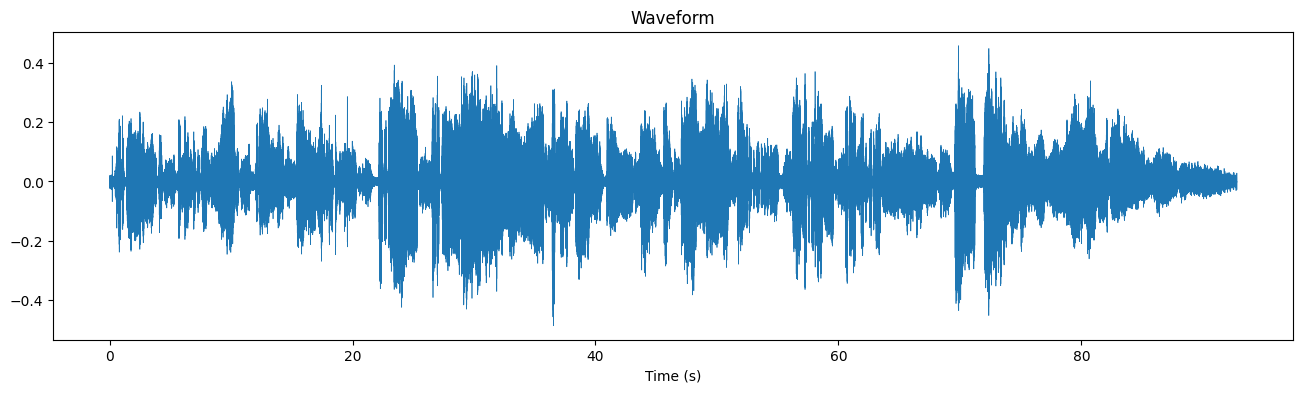

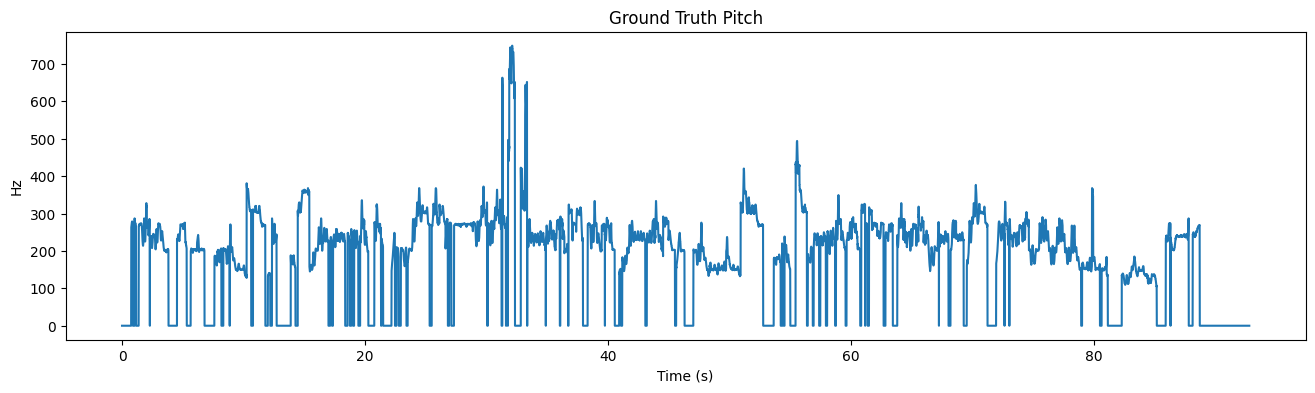

Duration : 92.801125
Frames : 20884
Tonic : 135.425885
Metadata:
{'mbid': 'ac58786c-3938-4d93-9e9f-bbc3a56265fa', 'title': 'Shlokam - Shivah Shaktyayukto', 'length': 92000, 'artists': [{'artist': {'mbid': '19f93366-5d58-47f1-bc4f-9225ac7af6ba', 'name': 'N Guruprasad'}, 'instrument': {'mbid': 'c5aa7d98-c14d-4ff1-8afb-f8743c62496c', 'name': 'Ghatam'}, 'lead': False, 'attributes': ''}, {'artist': {'mbid': '39c1d741-6154-418b-bf4b-12c77ba13873', 'name': 'Srimushnam V Raja Rao'}, 'instrument': {'mbid': 'f689271c-37bc-4c49-92a3-a14b15ee5d0e', 'name': 'Mridangam'}, 'lead': False, 'attributes': ''}, {'artist': {'mbid': 'a2df55e3-d141-4767-862e-77adca691d4b', 'name': 'B.U. Ganesh Prasad'}, 'instrument': {'mbid': '089f123c-0f7d-4105-a64e-49de81ca8fa4', 'name': 'Violin'}, 'lead': False, 'attributes': ''}, {'artist': {'mbid': 'e09b0542-84e1-45ad-b09a-a05a9ad0cb83', 'name': 'Cherthala Ranganatha Sharma'}, 'instrument': {'mbid': 'd92884b7-ee0c-46d5-96f3-918196ba8c5b', 'name': 'Voice'}, 'lead': True,

In [63]:
# ==========================================================
# Cell 11 : Visualize One Song
# ==========================================================

row = subset_df.iloc[0]

audio = load_audio(row.audio)

time, pitch = load_pitch(row.pitch)

tonic = load_tonic(row.tonic)

meta = load_metadata(row.json)

plt.figure(figsize=(16,4))

plt.plot(
    np.arange(len(audio))/SAMPLE_RATE,
    audio,
    linewidth=0.5
)

plt.title("Waveform")

plt.xlabel("Time (s)")

plt.show()

plt.figure(figsize=(16,4))

plt.plot(time, pitch)

plt.title("Ground Truth Pitch")

plt.xlabel("Time (s)")

plt.ylabel("Hz")

plt.show()

print("="*60)

print("Duration :", len(audio)/SAMPLE_RATE)

print("Frames :", len(pitch))

print("Tonic :", tonic)

print("Metadata:")

print(meta)

In [64]:
# ==========================================================
# Cell 6 : TorchCREPE Pitch Extraction
# ==========================================================

# Convert audio to torch tensor
audio_tensor = torch.tensor(audio, dtype=torch.float32)

# Shape : (1, samples)
audio_tensor = audio_tensor.unsqueeze(0).to(DEVICE)

# TorchCREPE inference
with torch.no_grad():

    pitch_pred, periodicity = torchcrepe.predict(

        audio_tensor,

        SAMPLE_RATE,

        HOP_LENGTH,

        fmin=50,

        fmax=1000,

        model="tiny",          # use "tiny" for faster experiments

        batch_size=256,

        device=DEVICE,

        return_periodicity=True

    )

# Convert to numpy
pitch_pred = pitch_pred.squeeze().cpu().numpy()

periodicity = periodicity.squeeze().cpu().numpy()

print("=" * 60)
print("TorchCREPE Results")
print("=" * 60)
print("Frames      :", len(pitch_pred))
print("Pitch Shape :", pitch_pred.shape)
print("Confidence  :", periodicity.shape)
print("Pitch Range :", np.nanmin(pitch_pred), "Hz -", np.nanmax(pitch_pred), "Hz")

TorchCREPE Results
Frames      : 9281
Pitch Shape : (9281,)
Confidence  : (9281,)
Pitch Range : 102.175964 Hz - 493.56686 Hz


In [ ]:
# ==========================================================
# Cell 6B : Visualize TorchCREPE Pitch
# ==========================================================

time_pitch = np.arange(len(pitch_pred)) * HOP_LENGTH / SAMPLE_RATE

plt.figure(figsize=(16,4))

plt.plot(
    time_pitch,
    pitch_pred,
    color="blue",
    linewidth=1
)

plt.title("TorchCREPE Estimated Pitch")

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")

plt.grid(True)

plt.show()

In [ ]:
# ==========================================================
# Cell 6C : Compare Ground Truth vs TorchCREPE
# ==========================================================

plt.figure(figsize=(16,5))

plt.plot(
    time,
    pitch,
    label="Ground Truth",
    linewidth=2
)

plt.plot(
    time_pitch,
    pitch_pred,
    alpha=0.7,
    label="TorchCREPE"
)

plt.xlabel("Time (s)")
plt.ylabel("Pitch (Hz)")
plt.title("Ground Truth vs TorchCREPE")

plt.legend()

plt.show()

In [57]:
# ==========================================================
# Cell 7 : Log-Mel Spectrogram
# ==========================================================

mel = librosa.feature.melspectrogram(
    y=audio,
    sr=SAMPLE_RATE,
    n_fft=1024,
    hop_length=HOP_LENGTH,
    win_length=1024,
    n_mels=N_MELS,
    fmin=20,
    fmax=8000,
    power=2.0
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

print("="*60)
print("Mel Spectrogram")
print("="*60)
print("Shape :", mel_db.shape)

Mel Spectrogram
Shape : (64, 9281)


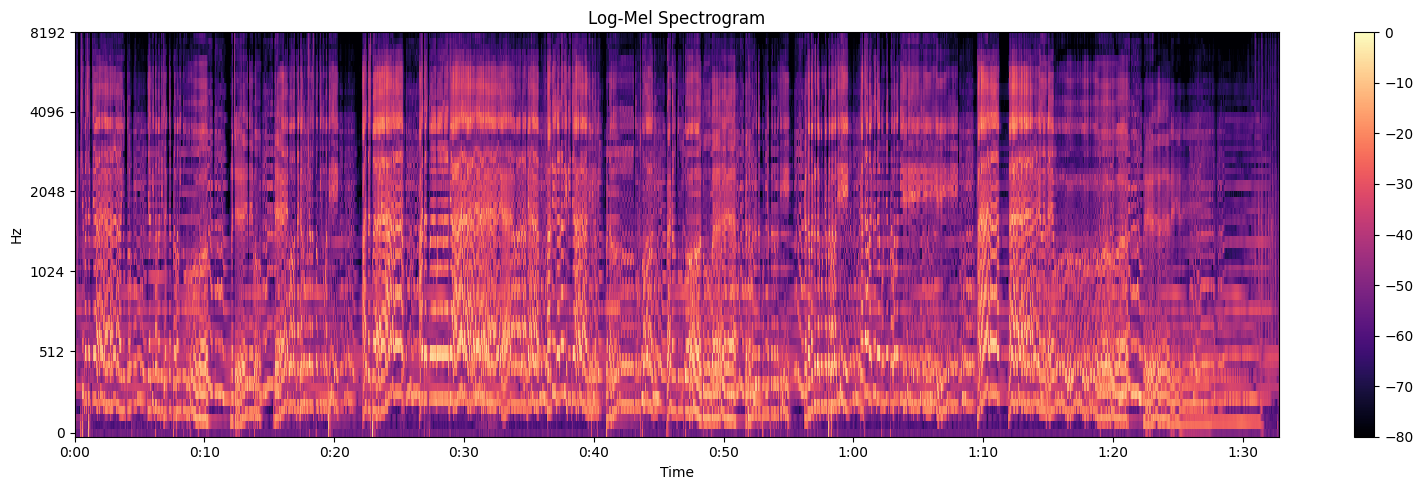

In [58]:
# ==========================================================
# Cell 8 : Visualize Mel Spectrogram
# ==========================================================

plt.figure(figsize=(16,5))

librosa.display.specshow(
    mel_db,
    sr=SAMPLE_RATE,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
    cmap="magma"
)

plt.colorbar()

plt.title("Log-Mel Spectrogram")

plt.tight_layout()

plt.show()

In [65]:
# ==========================================================
# Cell 9 : Load Ground Truth Pitch
# ==========================================================

gt = np.loadtxt(PITCH_FILE)

gt_time = gt[:,0]

gt_pitch = gt[:,1]

print("="*60)
print("Ground Truth")
print("="*60)
print("Frames :", len(gt_pitch))
print("Pitch Range :", gt_pitch.min(), "-", gt_pitch.max())

Ground Truth
Frames : 84721
Pitch Range : 0.0 - 784.0030517578125


In [66]:
# ==========================================================
# Cell 10 : Load Tonic
# ==========================================================

with open(TONIC_FILE) as f:
    tonic = float(f.read().strip())

print("Tonic :", tonic)

Tonic : 130.059356


In [67]:
# ==========================================================
# Cell 11 : Pitch → Swara Labels
# ==========================================================

SWARA_POS = np.array([
    0,
    100,
    200,
    300,
    500,
    700,
    900,
    1100
])

SWARA_NAMES = np.array([
    "S",
    "R",
    "G",
    "M",
    "P",
    "D",
    "N",
    "S"
])


def pitch_to_swara(pitch, tonic):

    labels = []

    for f in pitch:

        if f <= 0:

            labels.append(-1)

            continue

        cents = 1200 * np.log2(f / tonic)

        cents %= 1200

        idx = np.argmin(np.abs(cents - SWARA_POS))

        labels.append(idx)

    return np.array(labels)


swara_labels = pitch_to_swara(
    gt_pitch,
    tonic
)

print("Swara Frames :", len(swara_labels))

print("Unique Labels :", np.unique(swara_labels))

Swara Frames : 84721
Unique Labels : [-1  0  1  2  3  4  5  6  7]


In [68]:
# ==========================================================
# Cell 12 : Align Features
# ==========================================================

n = min(

    len(pitch_pred),

    len(periodicity),

    mel_db.shape[1],

    len(swara_labels)

)

pitch_pred = pitch_pred[:n]

periodicity = periodicity[:n]

mel_db = mel_db[:, :n]

swara_labels = swara_labels[:n]

print("="*60)
print("Aligned Length :", n)

Aligned Length : 9281


In [69]:
# ==========================================================
# Cell 13 : Build Feature Tensor
# ==========================================================

feature_tensor = np.concatenate(

    [

        mel_db.T,

        pitch_pred.reshape(-1,1),

        periodicity.reshape(-1,1)

    ],

    axis=1

)

print("="*60)
print("Feature Tensor")
print("="*60)

print(feature_tensor.shape)

print("Labels :", swara_labels.shape)

Feature Tensor
(9281, 66)
Labels : (9281,)


In [70]:
# ==========================================================
# Save Feature Tensor
# ==========================================================

song_name = os.path.basename(AUDIO_FILE).replace(".mp3.mp3","")

save_file = os.path.join(
    OUTPUT_DIR,
    song_name + ".npz"
)

np.savez_compressed(

    save_file,

    X=feature_tensor.astype(np.float32),

    y=swara_labels.astype(np.int64),

    pitch=pitch_pred.astype(np.float32),

    confidence=periodicity.astype(np.float32),

    tonic=np.float32(tonic)

)

print("="*60)
print("Saved Successfully")
print(save_file)
print("="*60)

Saved Successfully
/kaggle/working/SwaraFormer/dataset/processed/Geeta Nayakan.npz


In [71]:
# ==========================================================
# Verify Saved File
# ==========================================================

data = np.load(save_file)

print("="*60)

for k in data.files:

    print(k, data[k].shape if hasattr(data[k], "shape") else data[k])

print("="*60)

X (9281, 66)
y (9281,)
pitch (9281,)
confidence (9281,)
tonic ()


In [72]:
# ==========================================================
# Inspect One Feature Vector
# ==========================================================

print("Feature Dimension :", data["X"].shape)

print("Label Dimension   :", data["y"].shape)

print()

print("First Feature Vector")

print(data["X"][0])

print()

print("First Label")

print(data["y"][0])

Feature Dimension : (9281, 66)
Label Dimension   : (9281,)

First Feature Vector
[-7.7235168e+01 -7.8903122e+01 -7.9022675e+01 -7.6264366e+01
 -6.9169464e+01 -6.5309563e+01 -6.5638138e+01 -6.8257080e+01
 -6.7154099e+01 -6.6211304e+01 -6.7038780e+01 -6.8231155e+01
 -7.1330849e+01 -7.7498932e+01 -8.0000000e+01 -7.8535934e+01
 -7.6161613e+01 -7.1092697e+01 -6.6580902e+01 -6.6160950e+01
 -6.9766197e+01 -7.7507843e+01 -8.0000000e+01 -8.0000000e+01
 -8.0000000e+01 -8.0000000e+01 -8.0000000e+01 -8.0000000e+01
 -8.0000000e+01 -7.9644135e+01 -7.6250809e+01 -7.8179916e+01
 -8.0000000e+01 -8.0000000e+01 -8.0000000e+01 -8.0000000e+01
 -8.0000000e+01 -8.0000000e+01 -8.0000000e+01 -8.0000000e+01
 -8.0000000e+01 -8.0000000e+01 -8.0000000e+01 -8.0000000e+01
 -8.0000000e+01 -8.0000000e+01 -8.0000000e+01 -8.0000000e+01
 -8.0000000e+01 -8.0000000e+01 -8.0000000e+01 -8.0000000e+01
 -8.0000000e+01 -8.0000000e+01 -8.0000000e+01 -8.0000000e+01
 -8.0000000e+01 -8.0000000e+01 -8.0000000e+01 -8.0000000e+01
 -8.

In [73]:
# ==========================================================
# Cell 14 : Normalize Features
# ==========================================================

from sklearn.preprocessing import StandardScaler

# Mel normalization
mel_scaler = StandardScaler()

mel_norm = mel_scaler.fit_transform(mel_db.T)

# Pitch normalization (log scale)
pitch_log = np.log1p(pitch_pred)

pitch_scaler = StandardScaler()

pitch_norm = pitch_scaler.fit_transform(
    pitch_log.reshape(-1,1)
)

# Confidence normalization
conf_scaler = StandardScaler()

conf_norm = conf_scaler.fit_transform(
    periodicity.reshape(-1,1)
)

feature_tensor = np.concatenate(

    [

        mel_norm,

        pitch_norm,

        conf_norm

    ],

    axis=1

)

print(feature_tensor.shape)

(9281, 66)


In [74]:
# ==========================================================
# Cell 15 : Save Processed Song
# ==========================================================

song_name = os.path.basename(AUDIO_FILE)

song_name = song_name.replace(".mp3.mp3","")

save_file = os.path.join(
    OUTPUT_DIR,
    song_name + ".npz"
)

np.savez_compressed(

    save_file,

    X=feature_tensor.astype(np.float32),

    y=swara_labels.astype(np.int64),

    tonic=np.float32(tonic),

    song=song_name

)

print(save_file)

/kaggle/working/SwaraFormer/dataset/processed/Geeta Nayakan.npz


In [76]:
# ==========================================================
# Cell 16 : Production Batch Feature Extraction
# ==========================================================

from sklearn.preprocessing import StandardScaler
import traceback

processed = 0
skipped = 0
failed = 0

for idx, row in tqdm(songs_df.iterrows(),
                     total=len(songs_df)):

    try:

        ###################################################
        # Output filename
        ###################################################

        song_name = os.path.basename(
            row.audio
        ).replace(".mp3.mp3","")

        save_file = os.path.join(
            OUTPUT_DIR,
            song_name + ".npz"
        )

        ###################################################
        # Skip if already processed
        ###################################################

        if os.path.exists(save_file):

            skipped += 1
            continue

        ###################################################
        # Load audio
        ###################################################

        audio, sr = librosa.load(

            row.audio,

            sr=SAMPLE_RATE,

            mono=True

        )

        ###################################################
        # TorchCREPE
        ###################################################

        audio_tensor = torch.tensor(
            audio,
            dtype=torch.float32
        ).unsqueeze(0).to(DEVICE)

        with torch.no_grad():

            pitch_pred, periodicity = torchcrepe.predict(

                audio_tensor,

                SAMPLE_RATE,

                HOP_LENGTH,

                fmin=50,

                fmax=1000,

                model="tiny",

                batch_size=256,

                device=DEVICE,

                return_periodicity=True

            )

        pitch_pred = pitch_pred.squeeze().cpu().numpy()

        periodicity = periodicity.squeeze().cpu().numpy()

        ###################################################
        # Log-Mel
        ###################################################

        mel = librosa.feature.melspectrogram(

            y=audio,

            sr=SAMPLE_RATE,

            n_fft=1024,

            hop_length=HOP_LENGTH,

            win_length=1024,

            n_mels=N_MELS,

            power=2.0

        )

        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        ###################################################
        # Ground Truth
        ###################################################

        gt = np.loadtxt(row.pitch)

        gt_pitch = gt[:,1]

        with open(row.tonic) as f:

            tonic = float(f.read())

        swara_labels = pitch_to_swara(
            gt_pitch,
            tonic
        )

        ###################################################
        # Align
        ###################################################

        n = min(

            len(pitch_pred),

            len(periodicity),

            mel_db.shape[1],

            len(swara_labels)

        )

        mel_db = mel_db[:, :n]

        pitch_pred = pitch_pred[:n]

        periodicity = periodicity[:n]

        swara_labels = swara_labels[:n]

        ###################################################
        # Normalize
        ###################################################

        mel_norm = StandardScaler().fit_transform(
            mel_db.T
        )

        pitch_norm = StandardScaler().fit_transform(
            np.log1p(pitch_pred).reshape(-1,1)
        )

        conf_norm = StandardScaler().fit_transform(
            periodicity.reshape(-1,1)
        )

        X = np.concatenate(

            [

                mel_norm,

                pitch_norm,

                conf_norm

            ],

            axis=1

        )

        ###################################################
        # Save
        ###################################################

        np.savez_compressed(

            save_file,

            X=X.astype(np.float32),

            y=swara_labels.astype(np.int64),

            tonic=np.float32(tonic),

            song=song_name

        )

        processed += 1

        if processed % 10 == 0:

            print(
                f"\nProcessed : {processed} | "
                f"Skipped : {skipped} | "
                f"Failed : {failed}"
            )

    except Exception as e:

        failed += 1

        print("\nERROR :", row.audio)

        print(e)

        traceback.print_exc()

        continue

print("\n" + "="*60)
print("Feature Extraction Complete")
print("="*60)

print("Processed :", processed)
print("Skipped   :", skipped)
print("Failed    :", failed)

  9%|▉         | 11/116 [25:12<5:59:40, 205.53s/it]


Processed : 10 | Skipped : 1 | Failed : 0


 18%|█▊        | 21/116 [52:21<4:53:11, 185.17s/it]


Processed : 20 | Skipped : 1 | Failed : 0


 27%|██▋       | 31/116 [1:08:10<1:43:48, 73.28s/it] 

...


Processed : 100 | Skipped : 2 | Failed : 0


 97%|█████████▋| 113/116 [4:14:17<06:27, 129.12s/it]


Processed : 110 | Skipped : 3 | Failed : 0


100%|██████████| 116/116 [4:22:58<00:00, 136.02s/it]


Feature Extraction Complete
Processed : 113
Skipped   : 3
Failed    : 0
